# Training the XGBoost recommender

This notebook walks through exactly how `ml-service` trains its model, using the **same code the service runs** (`app.db`, `app.features`, `app.model`), so what you see here is what serves the checkout page.

**The question the model answers:** *given everything we know about a customer up to now, how likely is it that product P is in their **next** order?*

Every product gets a probability; the top candidates are then handed to the LLM, which picks and orders the final list by relevance.

**Before running:** PostgreSQL from the shoppingwebsite project must be up on `localhost:5432` with `seed.sql` loaded, and the kernel must be the `ml-service/.venv` interpreter (`make install && make notebook` from the repo root sets both up).

In [1]:
import os
import sys
from pathlib import Path

# Make `app` importable whether Jupyter was started from ml-service/ or notebooks/
ROOT = Path.cwd() if (Path.cwd() / "app").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

# Training never calls the LLM; set a provider so settings validation passes without an API key
os.environ.setdefault("LLM_PROVIDER", "ollama")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupShuffleSplit

from app.db import load_shop_data
from app.features import FEATURE_COLUMNS, NEIGHBOURS_K, REGION_SMOOTHING, build_features
from app.model import _XGB_PARAMS, _hit_rate, _new_classifier, make_training_set

pd.set_option("display.max_columns", 30)
print("xgboost", xgboost.__version__)

Matplotlib is building the font cache; this may take a moment.


Fontconfig warning: ignoring UTF-8: not a valid region tag


xgboost 3.4.1


## 1. Load the data

`load_shop_data()` reads four tables from the shoppingwebsite database in one read-only transaction:

| Table | Used for |
|---|---|
| `products` (+ `productcategory`) | the catalogue: price, category |
| `users` | email lookup, sign-up date (tenure) |
| `orders` | who ordered, when, and the shipping **state** (our "region") |
| `order_products` | what was in each order |

`order_products` is a snapshot of the product at order time and has **no `productid`**, so lines are joined back to the catalogue by `title` (unique in `products`).

In [2]:
data = load_shop_data()
print(f"{len(data.products)} products, {len(data.users)} users, {len(data.lines)} order lines, "
      f"{data.lines['orderid'].nunique()} orders")
data.lines.head()

36 products, 303 users, 3331 order lines, 1504 orders


,orderid,userid,orderdate,state,price,quantity,productid
0,bb631dd9-fde3-4237-af29-b3348b72f7c9,38956b43-32d8-4ef3-b7aa-e6884f1c2343,2026-10-04 21:02:25.061,Texas,59.99,2,3139d32c-93cd-59bf-5c94-1cf0dc98d2c1
1,bb631dd9-fde3-4237-af29-b3348b72f7c9,38956b43-32d8-4ef3-b7aa-e6884f1c2343,2026-10-04 21:02:25.061,Texas,149.99,1,c241330b-01a9-e71f-de8a-774bcf36d58b
2,bb631dd9-fde3-4237-af29-b3348b72f7c9,38956b43-32d8-4ef3-b7aa-e6884f1c2343,2026-10-04 21:02:25.061,Texas,39.99,1,6c307511-b2b9-437a-28df-6ec4ce4a2bbd
3,bb631dd9-fde3-4237-af29-b3348b72f7c9,38956b43-32d8-4ef3-b7aa-e6884f1c2343,2026-10-04 21:02:25.061,Texas,29.99,1,a9488d99-0bbb-2599-11ce-5dd2b45ed1f0
4,bb631dd9-fde3-4237-af29-b3348b72f7c9,38956b43-32d8-4ef3-b7aa-e6884f1c2343,2026-10-04 21:02:25.061,Texas,49.99,1,ddd1dfb2-3b98-2ef8-daf6-1a26146d3f31


## 2. Build a leak-free training set

The most common mistake in recommender training is **leakage**: computing features from the very purchase you are trying to predict. To avoid it we split time per customer:

1. For every customer with **2+ orders**, their **most recent order is the target**.
2. Features are computed from **all order lines except every customer's most recent order** (so neither the customer's own target nor anyone else's latest order leaks into popularity, region or similarity statistics).
3. Recency features ("days since last order") are measured **as of the target order's date**, which is exactly the situation at checkout: we know the past and are predicting the next basket.
4. One row per (customer, product): **label = 1** if the product is in the target order, else **0**.

At serving time the same `build_features()` runs with *all* orders as history and *now* as the reference date.

In [3]:
features, labels = make_training_set(data)
print(f"rows: {len(features):,}  customers: {features['userid'].nunique()}  "
      f"products: {features['productid'].nunique()}")
print(f"positive rate: {labels.mean():.3%}  (≈ {labels.sum()} positives)")
features.head()

rows: 8,856  customers: 246  products: 36
positive rate: 6.007%  (≈ 532 positives)


,userid,productid,user_n_orders,user_n_items,user_total_spend,user_avg_order_value,user_days_since_last_order,user_tenure_days,product_price,product_category_code,product_global_popularity,times_bought,days_since_bought,category_affinity,price_ratio_to_user_avg,regional_popularity,region_lift,similar_customers_score,copurchase_max,copurchase_mean
0,0299436a-8e48-5223-46b9-8991e14eb70d,0e51f30d-c6a7-ee39-c4b0-32ccd7c524a5,4.0,15.0,627.85,156.9625,8.0,279.0,29.99,5.0,0.246032,3.0,264.191933,0.333333,0.716493,0.262871,1.068443,0.668998,0.425277,0.293884
1,0299436a-8e48-5223-46b9-8991e14eb70d,10f1bc81-448a-aa9e-66b2-bc5b50c187fc,4.0,15.0,627.85,156.9625,8.0,279.0,19.99,5.0,0.261905,2.0,264.191933,0.333333,0.477582,0.298344,1.139130,0.706268,0.438248,0.314956
2,0299436a-8e48-5223-46b9-8991e14eb70d,17fc695a-07a0-ca6e-0822-e8f36c031199,4.0,15.0,627.85,156.9625,8.0,279.0,24.99,2.0,0.253968,0.0,NaN,0.133333,0.597038,0.254520,1.002174,0.453389,0.389711,0.314775
3,0299436a-8e48-5223-46b9-8991e14eb70d,1a2a73ed-562b-0f79-c374-59eef50bea63,4.0,15.0,627.85,156.9625,8.0,279.0,37.99,0.0,0.238095,0.0,NaN,0.066667,0.907621,0.279917,1.175652,0.398055,0.375735,0.299245
4,0299436a-8e48-5223-46b9-8991e14eb70d,23b8c1e9-3924-56de-3eb1-3b9046685257,4.0,15.0,627.85,156.9625,8.0,279.0,49.99,2.0,0.281746,1.0,272.771505,0.133333,1.194314,0.351380,1.247152,0.707763,0.438248,0.317025


## 3. The features

All features live in `app/features.py`. Each is computed only from the history passed in.

| Feature | Group | Meaning |
|---|---|---|
| `user_n_orders` | customer | number of past orders |
| `user_n_items` | customer | units bought in total |
| `user_total_spend` | customer | lifetime spend |
| `user_avg_order_value` | customer | spend / orders |
| `user_days_since_last_order` | customer | recency (NaN for cold-start customers; XGBoost handles NaN natively) |
| `user_tenure_days` | customer | days since sign-up |
| `product_price` | product | current price |
| `product_category_code` | product | category as an integer code (trees split on it fine) |
| `product_global_popularity` | product | share of active customers who ever bought it |
| `times_bought` | **past orders** | units of *this* product the customer bought before |
| `days_since_bought` | **past orders** | days since they last bought it (NaN if never) |
| `category_affinity` | **past orders** | share of the customer's units in this product's category |
| `price_ratio_to_user_avg` | **past orders** | product price / customer's average unit price (does it fit their budget?) |
| `regional_popularity` | **region** | share of customers in the same state who bought it, smoothed towards global popularity with a pseudo-count of 5 (`REGION_SMOOTHING`) customers so tiny states don't produce extreme values |
| `region_lift` | **region** | regional / global popularity (>1 = over-indexed locally) |
| `similar_customers_score` | **similar customers** | cosine-similarity-weighted share of the customer's **20 most similar customers** (by what they bought; `NEIGHBOURS_K`) who bought this product |
| `copurchase_max` / `copurchase_mean` | **similar customers** | item-to-item cosine similarity between this product and products the customer already owns (max / mean): "people who bought X also bought Y" |

A customer's **region** is the state they ship to most often (latest order wins ties).

In [4]:
features[FEATURE_COLUMNS].describe().T[["mean", "std", "min", "50%", "max"]].round(3)

,mean,std,min,50%,max
user_n_orders,5.089,2.350,1.000,5.000,12.000
user_n_items,15.886,8.706,1.000,15.000,45.000
user_total_spend,1123.607,788.109,12.990,947.840,4175.730
user_avg_order_value,215.749,127.026,12.990,192.055,1261.475
user_days_since_last_order,104.959,110.474,0.000,79.000,587.000
user_tenure_days,464.053,310.720,0.000,468.000,1055.000
product_price,69.102,93.491,12.990,39.990,549.000
product_category_code,2.500,1.708,0.000,2.500,5.000
product_global_popularity,0.262,0.027,0.206,0.258,0.321
times_bought,0.441,0.886,0.000,0.000,8.000


## 4. Is there anything to learn? (signal check)

Before trusting a model, check whether the features actually separate buyers from non-buyers. Below, for each signal we compare the purchase rate when the signal is high vs low. A **lift well above 1** means the signal is predictive.

In [5]:
frame = features.assign(label=labels.values)

def lift(mask):
    return frame.loc[mask, "label"].mean() / frame.loc[~mask, "label"].mean()

checks = {
    "category_affinity > median": frame.category_affinity > frame.category_affinity.median(),
    "bought before (times_bought > 0)": frame.times_bought > 0,
    "region_lift > 1.2": frame.region_lift > 1.2,
    "similar_customers_score top 25%": frame.similar_customers_score > frame.similar_customers_score.quantile(0.75),
    "copurchase_max top 25%": frame.copurchase_max > frame.copurchase_max.quantile(0.75),
    "global popularity > median": frame.product_global_popularity > frame.product_global_popularity.median(),
}
pd.Series({k: lift(m) for k, m in checks.items()}, name="lift").round(3).to_frame()

,lift
category_affinity > median,0.896
bought before (times_bought > 0),0.917
region_lift > 1.2,1.082
similar_customers_score top 25%,1.071
copurchase_max top 25%,1.024
global popularity > median,1.068


> **Reading this on the current seed data:** every lift is close to 1.0. The seeded orders appear to pick products essentially at random (customers are *not* more likely to rebuy their favourite categories, regions don't differ, and every product sells 106-161 units). The pipeline is correct, and the unit tests show the features capture preferences when they exist, but **no model can beat chance on random data**. With real shopping data (or a seed with category loyalty / regional tastes) these lifts rise above 1 and the model's AUC with them.

## 5. Hyperparameters

The classifier is `xgboost.XGBClassifier` with the parameters in `app/model.py::_XGB_PARAMS`:

| Parameter | Value | What it does / why this value |
|---|---|---|
| `n_estimators` | 300 | Number of boosted trees. Each tree corrects the previous ones' errors. 300 small trees with a low learning rate is a stable default for ~10k rows. |
| `max_depth` | 4 | Maximum depth of each tree, i.e. how many features one tree can combine (up to 4-way interactions such as *affinity × region × price fit*). Shallow trees generalise better on small data. |
| `learning_rate` (eta) | 0.05 | Shrinks each tree's contribution. Lower = slower but less overfitting; pairs with the larger `n_estimators`. |
| `subsample` | 0.8 | Each tree sees a random 80% of rows: bagging-style noise that reduces overfitting. |
| `colsample_bytree` | 0.8 | Each tree sees a random 80% of the features, so no single feature dominates and trees decorrelate. |
| `min_child_weight` | 2 | Minimum summed hessian (≈ number of examples for logistic loss) in a leaf. Blocks leaves built on one or two rows. |
| `eval_metric` | `"auc"` | Metric reported during evaluation. AUC measures ranking quality, which is what a recommender needs, not accuracy (a model saying "nobody buys anything" is 94% accurate here). |
| `tree_method` | `"hist"` | Histogram-based split finding: fast, memory-efficient, the modern default. |
| `random_state` | 42 | Seed for subsampling, so retraining is reproducible. |
| `scale_pos_weight` | negatives / positives (≈ 15) | Set per training run in `_new_classifier`. Only about 6% of rows are positive; this up-weights positives so the loss doesn't ignore them. |

The objective is the default `binary:logistic`, so `predict_proba` returns a purchase probability in [0, 1] (the `model_score` you see in API responses).

In [6]:
pd.Series(_XGB_PARAMS, name="value").to_frame()

,value
n_estimators,300
max_depth,4
learning_rate,0.05
subsample,0.8
colsample_bytree,0.8
min_child_weight,2
eval_metric,auc
tree_method,hist
random_state,42


## 6. Train / evaluate split by customer

We hold out **20% of customers** (not 20% of rows) with `GroupShuffleSplit`, grouping on `userid`. If rows from the same customer landed in both train and test, the model could memorise customer-level features and look better than it is.

In [7]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(features, labels, features["userid"]))
X = features[FEATURE_COLUMNS]
print(f"train rows {len(train_idx):,} ({features.iloc[train_idx]['userid'].nunique()} customers), "
      f"test rows {len(test_idx):,} ({features.iloc[test_idx]['userid'].nunique()} customers)")

model = _new_classifier(labels.iloc[train_idx])
print("scale_pos_weight =", round(model.get_params()["scale_pos_weight"], 2))
model.fit(
    X.iloc[train_idx], labels.iloc[train_idx],
    eval_set=[(X.iloc[train_idx], labels.iloc[train_idx]), (X.iloc[test_idx], labels.iloc[test_idx])],
    verbose=False,
)

train rows 7,056 (196 customers), test rows 1,800 (50 customers)
scale_pos_weight = 15.68


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### Learning curve

AUC on the training customers vs the held-out customers, tree by tree. A widening gap means the model is memorising rather than learning.

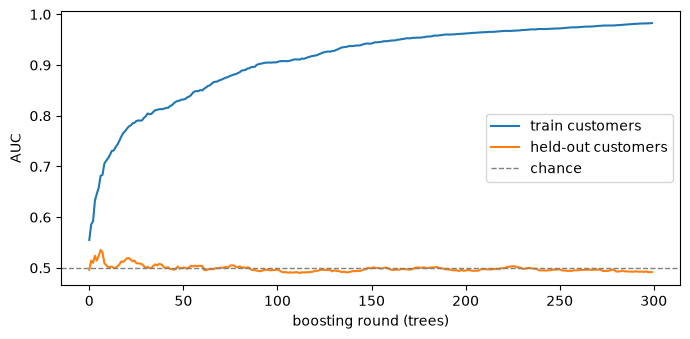

In [8]:
history = model.evals_result()
plt.figure(figsize=(7, 3.5))
plt.plot(history["validation_0"]["auc"], label="train customers")
plt.plot(history["validation_1"]["auc"], label="held-out customers")
plt.axhline(0.5, color="grey", linestyle="--", linewidth=1, label="chance")
plt.xlabel("boosting round (trees)")
plt.ylabel("AUC")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Metrics

- **AUC**: probability that a random bought product scores above a random not-bought one (0.5 = chance, 1.0 = perfect).
- **Hit-rate@k**: share of held-out customers for whom at least one product from their real next order appears in our top-k. It mirrors the live policy: already-bought products are excluded, and k is the recommendation count.
- **Popularity baseline**: the same hit-rate using "most popular products" only. A useful model must beat it.

In [9]:
K = 5
test_frame, test_labels = features.iloc[test_idx], labels.iloc[test_idx]
scores = model.predict_proba(X.iloc[test_idx])[:, 1]

print(f"held-out AUC           : {roc_auc_score(test_labels, scores):.3f}")
print(f"hit-rate@{K} (model)     : {_hit_rate(test_frame, scores, test_labels, K, exclude_purchased=True):.3f}")
print(f"hit-rate@{K} (popularity): {_hit_rate(test_frame, test_frame['product_global_popularity'].to_numpy(), test_labels, K, exclude_purchased=True):.3f}")

held-out AUC           : 0.492
hit-rate@5 (model)     : 0.280
hit-rate@5 (popularity): 0.400


## 8. Feature importance

`feature_importances_` uses XGBoost's default **gain**-based importance for tree models: how much each feature improved the loss when used in a split. On data with no real signal the importances are flat; with real signal, a few features (typically category affinity, similar-customer and co-purchase scores) dominate.

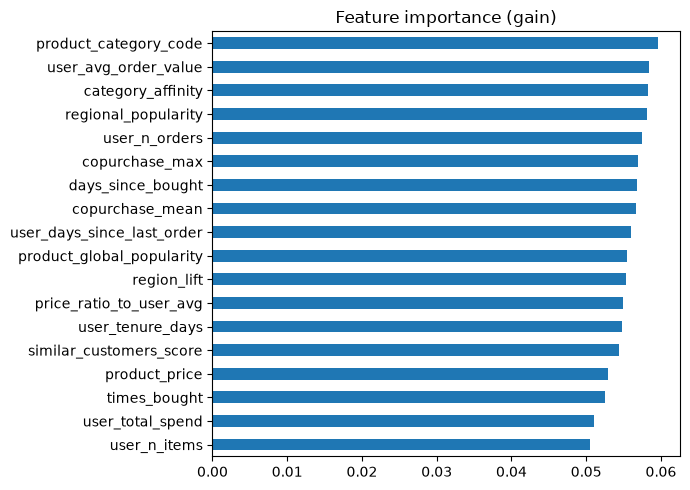

In [10]:
importance = pd.Series(model.feature_importances_, index=FEATURE_COLUMNS).sort_values()
importance.plot.barh(figsize=(7, 5), title="Feature importance (gain)")
plt.tight_layout()
plt.show()

## 9. Score one customer, exactly as the API does

At serving time the history is **all** orders and the reference date is **now**. Products already bought are dropped (`EXCLUDE_PURCHASED_PRODUCTS=true`), and the top `CANDIDATE_POOL_SIZE` go to the LLM.

In [11]:
email = "chris.walker@example.com"
userid = data.users.loc[data.users["email"] == email, "userid"].iloc[0]

live = build_features(data.products, data.users, data.lines, [userid], pd.Series({userid: pd.Timestamp.now()}))
live["model_score"] = model.predict_proba(live[FEATURE_COLUMNS])[:, 1]
catalogue = data.products.set_index("productid")
live = live.join(catalogue[["title", "category_name", "price"]], on="productid")

already = live["times_bought"] > 0
print(f"{email}: {int(already.sum())} products already bought (excluded)")
live.loc[~already].sort_values("model_score", ascending=False)[
    ["title", "category_name", "price", "model_score", "category_affinity",
     "regional_popularity", "similar_customers_score", "copurchase_max"]
].head(15).round(3)

chris.walker@example.com: 7 products already bought (excluded)


,title,category_name,price,model_score,category_affinity,regional_popularity,similar_customers_score,copurchase_max
19,Kids Art & Craft Kit,Toys & Games,24.99,0.650,0.1,0.336,0.426,0.397
5,Yoga Mat Extra Thick,Sports & Outdoors,24.99,0.625,0.3,0.268,0.192,0.398
17,Bamboo Cutting Board,Home & Kitchen,19.99,0.587,0.1,0.271,0.235,0.339
22,Camping Tent 4-Person,Sports & Outdoors,119.99,0.559,0.3,0.268,0.179,0.345
26,Building Blocks Classic Set,Toys & Games,34.99,0.553,0.1,0.339,0.189,0.420
1,Plush Teddy Bear,Toys & Games,19.99,0.544,0.1,0.271,0.441,0.423
0,Strategy Board Game,Toys & Games,29.99,0.537,0.1,0.261,0.090,0.366
11,Cotton Crew Neck T-Shirt,Clothing,14.99,0.525,0.0,0.342,0.239,0.384
8,Mountain Bike Helmet,Sports & Outdoors,54.99,0.503,0.3,0.336,0.153,0.412
33,Stainless Steel Cookware Set,Home & Kitchen,129.99,0.499,0.1,0.271,0.376,0.374


## 10. Train the serving model

The service evaluates on the split above, then **refits on all customers** and saves `artifacts/xgb_recommender.json` plus a metrics file. You can trigger the same thing on a running service with `POST /model/train` (or `make train`). The cell below does it from the notebook; the running service picks the new file up on its next start.

In [12]:
from app.config import get_settings
from app.model import train_model

settings = get_settings()
final_model, metrics = train_model(
    data, settings.model_dir, k=settings.recommendation_count,
    exclude_purchased=settings.exclude_purchased_products,
)
print("saved to", settings.model_dir)
{k: v for k, v in metrics.__dict__.items() if k != "feature_importance"}

saved to /Users/harmanbirsinghrai/HarmanData/VSCodeRepository/RecommedationSystem/ml-service/artifacts


{'trained_at': '2026-10-05T17:20:54+00:00',
 'n_training_rows': 8856,
 'n_customers': 246,
 'positive_rate': 0.0601,
 'holdout_auc': 0.4919,
 'holdout_hit_rate_at_k': 0.28,
 'baseline_popularity_hit_rate_at_k': 0.4,
 'k': 5}